# 14 — Diversity Metric Instrumentation

**Maps to:** `report/Chapters/Task2.tex` §`T2:RepairEffect` (and feeds Task 3 critique).  
**Ticket:** TICKET-14.

Pairwise Hamming diversity on the population each generation. Verify metric values make sense on a hand-crafted population before plugging into the loop.

## Metric Definition

`pairwise_hamming(population)`: average pairwise Hamming distance, normalised by chromosome length to [0, 1]. This measures positional diversity and is the metric expected by downstream plotting notebooks under the column name `diversity`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _as_population(population):
    pop = np.asarray(population)
    if pop.ndim != 2:
        raise ValueError("population must be a 2D array-like object")
    if pop.shape[1] == 0:
        raise ValueError("chromosomes must contain at least one city")
    return pop


def pairwise_hamming(population):
    """Return mean pairwise Hamming distance, normalised to [0, 1]."""
    pop = _as_population(population)
    n_individuals, n_genes = pop.shape

    if n_individuals < 2:
        return 0.0

    total = 0.0
    n_pairs = 0
    for i in range(n_individuals - 1):
        total += np.count_nonzero(pop[i] != pop[i + 1:], axis=1).sum()
        n_pairs += n_individuals - i - 1

    return float(total / (n_pairs * n_genes))


def diversity_record(generation, population):
    """Create one per-generation diversity log row."""
    pop = _as_population(population)
    return {
        "generation": int(generation),
        "pop_size": int(pop.shape[0]),
        "n_cities": int(pop.shape[1]),
        "diversity": pairwise_hamming(pop),
    }

## Hand-Crafted Validation

The first validation population contains three identical tours, so Hamming diversity is zero.

The second population is small enough to verify by hand:

- `a = [0, 1, 2, 3]`
- `b = [0, 2, 1, 3]`
- `c = [3, 2, 1, 0]`

For Hamming distance, the pairwise normalised distances are `0.50`, `1.00`, and `0.50`, so the average is `2/3`.

In [2]:
identical_pop = np.array([
    [0, 1, 2, 3],
    [0, 1, 2, 3],
    [0, 1, 2, 3],
])

mixed_pop = np.array([
    [0, 1, 2, 3],
    [0, 2, 1, 3],
    [3, 2, 1, 0],
])

assert pairwise_hamming(identical_pop) == 0.0
assert np.isclose(pairwise_hamming(mixed_pop), 2 / 3)

print("Identical population")
print(diversity_record(0, identical_pop))
print()
print("Mixed population")
print(diversity_record(1, mixed_pop))
print()
print("Validation passed.")

Identical population
{'generation': 0, 'pop_size': 3, 'n_cities': 4, 'diversity': 0.0}

Mixed population
{'generation': 1, 'pop_size': 3, 'n_cities': 4, 'diversity': 0.6666666666666666}

Validation passed.


## Structured Per-Generation Log

The GA loop should append one row per generation with the same structure used below. The `diversity` column is normalised Hamming distance, compatible with notebooks 15, 17, and 18.

In [3]:
base = np.array([0, 1, 2, 3, 4, 5])
population_by_generation = [
    np.array([
        base,
        [0, 1, 2, 3, 5, 4],
        [0, 2, 1, 3, 4, 5],
        [5, 4, 3, 2, 1, 0],
    ]),
    np.array([
        base,
        base,
        [0, 1, 2, 3, 5, 4],
        [0, 2, 1, 3, 4, 5],
    ]),
    np.array([
        base,
        base,
        base,
        [0, 1, 2, 3, 5, 4],
    ]),
    np.array([
        base,
        base,
        base,
        base,
    ]),
]

diversity_log = pd.DataFrame(
    diversity_record(gen, pop)
    for gen, pop in enumerate(population_by_generation)
)

diversity_log

,generation,pop_size,n_cities,diversity
0,0,4,6,0.722222
1,1,4,6,0.333333
2,2,4,6,0.166667
3,3,4,6,0.000000


## Sample Plot

The example below simulates diversity collapse as a population converges. In real experiment notebooks, the same columns can be grouped by seed, repair strategy, or generation.


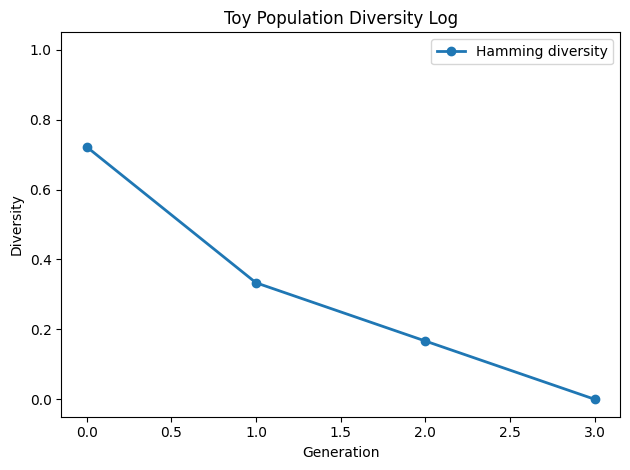

In [5]:
fig, ax = plt.subplots()

ax.plot(diversity_log["generation"], diversity_log["diversity"],
        marker="o", linewidth=2, label="Hamming diversity")

ax.set_xlabel("Generation")
ax.set_ylabel("Diversity")
ax.set_title("Toy Population Diversity Log")
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## Integration Note

`run_ga` in `10_ga_loop.ipynb` can call `pairwise_hamming` at the same point where it records best and mean fitness. The hook is controlled by `GAConfig.instrument_diversity`, so normal fitness logging remains available when diversity instrumentation is turned off. When enabled, the resulting per-generation log includes columns:

`generation`, `best_fitness`, `mean_fitness`, `diversity`.